<hr style='border-top:4px solid #1F77B4;'>

<h2><span style="color: #1F77B4; font-size: 35px">Chapitre 13</span></h2>
<h1><span style="color: #1F77B4; font-size: 50px">Règles d'association</span></h1>

Ce carnet reprend, dans l'ordre du chapitre, l'ensemble des extraits de code présentés dans le texte : lecture et encodage transactionnel, fréquence des items, extraction des itemsets fréquents par Apriori, comparaison avec FP-Growth, génération des règles d'association et synthèses visuelles. Il permet également de régénérer les figures associées selon les conventions graphiques du livre. Le fil conducteur est le jeu de données <i>Groceries_dataset</i>. Les cellules doivent être exécutées séquentiellement, car chaque étape réutilise les résultats de la précédente.

**Bibliothèques requises** : `numpy`, `pandas`, `matplotlib` et `mlxtend`.  
**Installation complémentaire** : `mlxtend` s'installe avec `pip install mlxtend`.  
**Données externes** : le fichier `./data/Groceries_dataset.csv` doit se trouver dans le sous-dossier `data`.  
**Exécution** : les versions utilisées sont affichées par la cellule de configuration ; l'exécution complète prend moins d'une minute.

<hr style='border-top:4px solid #1F77B4;'>

In [1]:
# Configuration générale : bibliothèques, versions et affichage
import sys
from importlib.metadata import version as package_version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PAQUETS = ('numpy', 'pandas', 'matplotlib', 'mlxtend')

print(f"{'python':<18} {sys.version.split()[0]}")
for paquet in PAQUETS:
    print(f"{paquet:<18} {package_version(paquet)}")

plt.rcParams.update({
    'font.size': 13,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'mathtext.fontset': 'cm',
    'text.usetex': False,
})

# Couleurs du livre (palette viridis)
VIOLET, SARCELLE, VERT, BLEU, MAGENTA = '#482878', '#21918c', '#5ec962', '#3b528b', '#bf00bf'
BORD    = {VIOLET: '#2e1a4d', SARCELLE: '#14615d', VERT: '#3a7d3f', BLEU: '#2c3e6b', MAGENTA: '#8a008a'}
PALETTE = [VIOLET, SARCELLE, VERT, BLEU, MAGENTA]

python             3.12.13
numpy              2.5.1
pandas             3.0.3
matplotlib         3.11.0
mlxtend            0.25.0


In [2]:
# Fonction utilitaire de sauvegarde des figures (PDF)
import os

def save_figure(fig, path):
    directory = os.path.dirname(path)
    if directory:
        os.makedirs(directory, exist_ok=True)
    fig.savefig(f"{path}.pdf", format="pdf", bbox_inches='tight')

<hr style='border-top:4px solid #1F77B4;'>

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 13.1 : Lecture et encodage des données <i>Groceries_dataset</i></h3>

In [3]:
from mlxtend.preprocessing import TransactionEncoder

# Lecture des donnees
data = pd.read_csv("./data/Groceries_dataset.csv")

# Regroupement de l'ensemble des achats par client.
# Chaque client est représenté par un profil d'achat regroupant
# tous les items achetés au moins une fois durant la période observée.
transactions = (data.groupby('Member_number')['itemDescription']
                .apply(list).values.tolist())

# Encodage binaire des profils d'achat clients
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_ary, columns=te.columns_)

print("Dimensions de la matrice :", df.shape)
display(df.head())

Dimensions de la matrice : (3898, 167)


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,True,False,...,False,False,False,True,False,True,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 13.2 : Fréquence des items et figure</h3>

whole milk          1786
other vegetables    1468
rolls/buns          1363
soda                1222
yogurt              1103
tropical fruit       911
root vegetables      899
bottled water        833
sausage              803
citrus fruit         723
dtype: int64


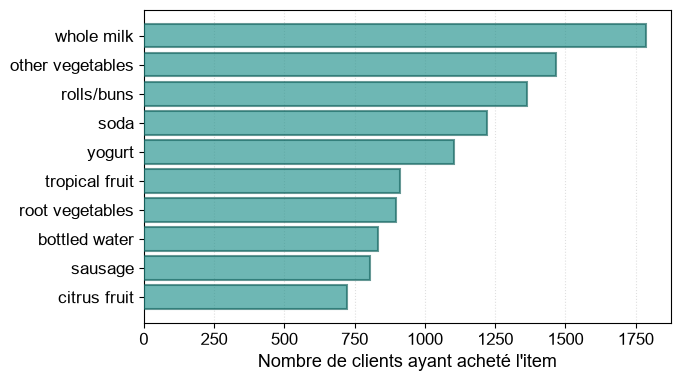

In [4]:
# Fréquence de chaque item (nombre de profils clients)
item_frequencies = df.sum().sort_values(ascending=False)
print(item_frequencies.head(10))

# Diagramme en barres des dix items les plus fréquents
top10 = item_frequencies.head(10)

fig, ax = plt.subplots(figsize=(7, 4))

ax.barh(top10.index[::-1], top10.values[::-1], color=SARCELLE,
        edgecolor=BORD[SARCELLE], linewidth=1.5, alpha=0.65, zorder=3)

ax.set_xlabel("Nombre de clients ayant acheté l'item", fontsize=13)
ax.tick_params(axis='both', labelsize=12)
ax.grid(axis='x', alpha=0.4, linestyle=':', zorder=0)

fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap13_TopItems')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 13.3 : Génération des ensembles d'items fréquents</h3>

In [5]:
from mlxtend.frequent_patterns import apriori, association_rules

# Extraction des itemsets fréquents
# (présents dans au moins 1 % des profils clients)
frequent_itemsets = apriori(df, min_support=0.01,
                            use_colnames=True)

print(frequent_itemsets.head())
print("Nombre d'itemsets frequents :", len(frequent_itemsets))

    support                            itemsets
0  0.015393  frozenset({Instant food products})
1  0.078502               frozenset({UHT-milk})
2  0.031042          frozenset({baking powder})
3  0.119548                   frozenset({beef})
4  0.079785                frozenset({berries})
Nombre d'itemsets frequents : 3016


In [6]:
itemsets_display = (
    frequent_itemsets
    .assign(nombre_items=lambda x: x['itemsets'].apply(len))
    .sort_values(
        ['support', 'nombre_items'],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

display(itemsets_display.head())

,support,itemsets,nombre_items
0,0.458184,frozenset({whole milk}),1
1,0.376603,frozenset({other vegetables}),1
2,0.349666,frozenset({rolls/buns}),1
3,0.313494,frozenset({soda}),1
4,0.282966,frozenset({yogurt}),1


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 13.4 : Comparaison des temps d'exécution d'Apriori et de FP-Growth</h3>

In [7]:
import time
from mlxtend.frequent_patterns import fpgrowth

t0 = time.perf_counter()
fi_apriori = apriori(df, min_support=0.01, use_colnames=True)
t_apriori = time.perf_counter() - t0

t0 = time.perf_counter()
fi_fpgrowth = fpgrowth(df, min_support=0.01, use_colnames=True)
t_fpgrowth = time.perf_counter() - t0

print(f"Apriori   -> itemsets : {len(fi_apriori)} | temps : {t_apriori:.3f} s")
print(f"FP-Growth -> itemsets : {len(fi_fpgrowth)} | temps : {t_fpgrowth:.3f} s")

Apriori   -> itemsets : 3016 | temps : 0.177 s
FP-Growth -> itemsets : 3016 | temps : 0.361 s


**Complément** : dans cette exécution, Apriori est plus rapide au seuil de support de 1 %, tandis que l'écart devient favorable à FP-Growth lorsque le seuil diminue. Les temps mesurés restent toutefois indicatifs, car ils dépendent de la machine, de la charge du système et des versions des bibliothèques utilisées.

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 13.5 : Comparaison des deux algorithmes à quatre seuils de support</h3>

In [8]:
seuils         = [0.010, 0.005, 0.003, 0.002]
nb_itemsets    = []
temps_apriori  = []
temps_fpgrowth = []
rapports       = []

# Mesures
for seuil in seuils:
    t0 = time.perf_counter()
    a = apriori(df, min_support=seuil, use_colnames=True)
    ta = time.perf_counter() - t0

    t0 = time.perf_counter()
    f = fpgrowth(df, min_support=seuil, use_colnames=True)
    tf = time.perf_counter() - t0

    # Les deux algorithmes doivent extraire le meme nombre d'itemsets
    assert len(a) == len(f)

    nb_itemsets.append(len(a))
    temps_apriori.append(ta)
    temps_fpgrowth.append(tf)
    rapports.append(ta / tf)

# Affichage
print("=" * 60)
print("Apriori vs FP-Growth : temps d'exécution (s) selon le seuil")
print("=" * 60)
print(f"{'Seuil':<10}{'Itemsets':>11}{'Apriori':>12}"
      f"{'FP-Growth':>14}{'Rapport A/FP':>13}")
print("-" * 60)
for seuil, n, ta, tf, r in zip(seuils, nb_itemsets, temps_apriori, temps_fpgrowth, rapports):
    print(f"{seuil:<10.3f}{n:>11d}{ta:>12.3f}{tf:>14.3f}{r:>13.2f}")
print("=" * 60)

Apriori vs FP-Growth : temps d'exécution (s) selon le seuil
Seuil        Itemsets     Apriori     FP-Growth Rapport A/FP
------------------------------------------------------------
0.010            3016       0.215         0.362         0.59
0.005            9876       0.647         0.734         0.88
0.003           24807       1.725         1.632         1.06
0.002           52601       7.020         2.440         2.88


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 13.6 : Génération des règles d'association</h3>

In [9]:
# Génération des règles entre profils clients
# (confiance >= 30 %)
rules = association_rules(frequent_itemsets,
                          metric="confidence",
                          min_threshold=0.3)

# Selection des colonnes d'interet
rules_selected = rules[['antecedents', 'consequents',
                        'support', 'confidence', 'lift']]

display(rules_selected.head())
print("Nombre de regles :", len(rules))

,antecedents,consequents,support,confidence,lift
0,frozenset({UHT-milk}),frozenset({other vegetables}),0.038994,0.496732,1.318979
1,frozenset({UHT-milk}),frozenset({rolls/buns}),0.031042,0.395425,1.130863
2,frozenset({UHT-milk}),frozenset({soda}),0.027450,0.349673,1.115406
3,frozenset({UHT-milk}),frozenset({whole milk}),0.040534,0.516340,1.126928
4,frozenset({baking powder}),frozenset({other vegetables}),0.015136,0.487603,1.294740


Nombre de regles : 3398


**Complément : classement des règles par lift décroissant**

In [10]:
rules_selected_sorted = (
    rules[
        ['antecedents', 'consequents',
         'support', 'confidence', 'lift']
    ]
    .sort_values(
        ['lift', 'confidence', 'support'],
        ascending=False
    )
)

display(rules_selected_sorted.head())

,antecedents,consequents,support,confidence,lift
3381,"frozenset({sausage, rolls/buns, other vegetabl...","frozenset({whole milk, yogurt})",0.013597,0.325153,2.159196
2896,"frozenset({whole milk, frozen meals})","frozenset({rolls/buns, other vegetables})",0.010005,0.307087,2.092699
3372,"frozenset({bottled water, rolls/buns, yogurt})","frozenset({whole milk, other vegetables})",0.010518,0.398058,2.079934
3388,"frozenset({rolls/buns, shopping bags, yogurt})","frozenset({whole milk, other vegetables})",0.010005,0.397959,2.079417
2838,"frozenset({sausage, curd})","frozenset({whole milk, yogurt})",0.010005,0.312000,2.071850


Dans cette analyse, une règle \(X \rightarrow Y\) indique que, parmi les
clients ayant acheté les items de \(X\) au moins une fois durant la période
observée, une certaine proportion a également acheté les items de \(Y\).
Elle ne signifie pas nécessairement que \(X\) et \(Y\) ont été achetés
simultanément ou lors d'une même visite.

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 13.7a : Carte thermique des confiances (version simple)</h3>

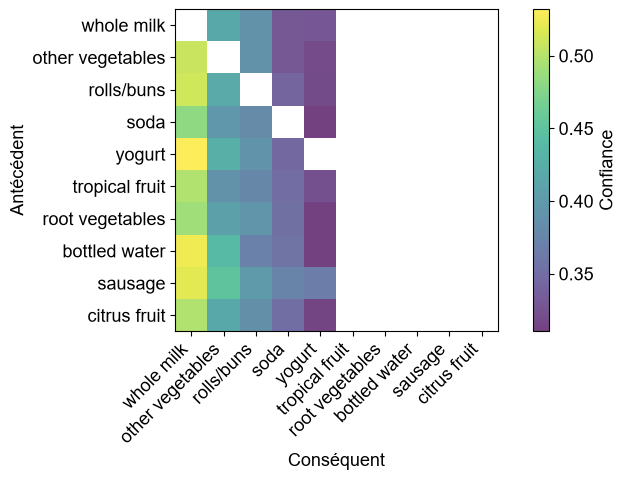

In [11]:
# Regles a antecedent et consequent uniques
r1 = rules[(rules.antecedents.apply(len) == 1)
           & (rules.consequents.apply(len) == 1)].copy()
r1['ant'] = r1.antecedents.apply(lambda s: list(s)[0])
r1['con'] = r1.consequents.apply(lambda s: list(s)[0])

# Tableau croise des confiances (dix items les plus frequents)
tops = list(item_frequencies.head(10).index)
pivot = (r1[r1.ant.isin(tops) & r1.con.isin(tops)]
         .pivot(index='ant', columns='con', values='confidence')
         .reindex(index=tops, columns=tops))

fig, ax = plt.subplots(figsize=(8, 5))

im = ax.imshow(pivot, cmap='viridis', alpha=0.75)
ax.set_xticks(range(len(tops)))
ax.set_xticklabels(tops, rotation=45, ha='right')
ax.set_yticks(range(len(tops)))
ax.set_yticklabels(tops)
ax.set_xlabel('Conséquent')
ax.set_ylabel('Antécédent')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Confiance')
fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap13_HeatMap')

plt.show()

Les cases blanches correspondent à la diagonale ou à l'absence d'une règle satisfaisant simultanément les seuils de support et de confiance sélectionnés.

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 13.7b : Carte thermique des confiances (version annotée)</h3>

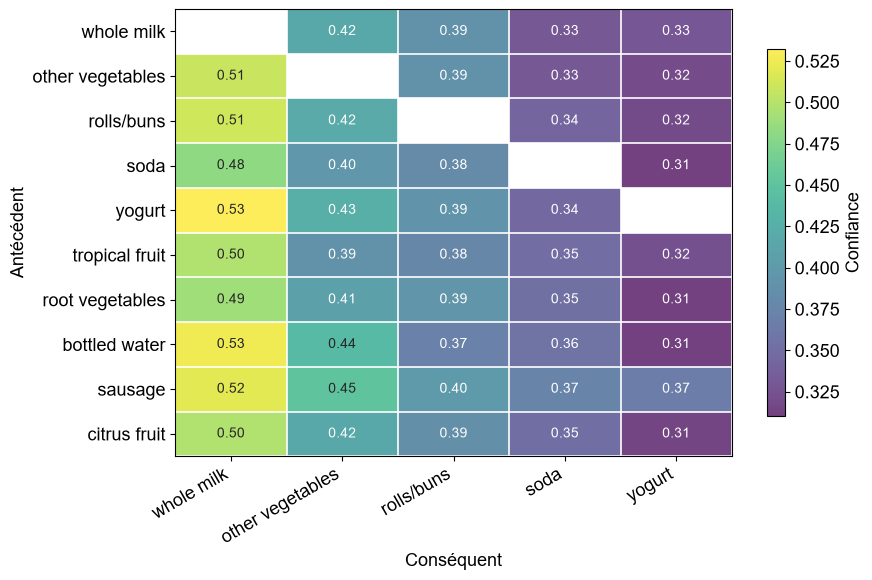

In [12]:
# Figure Fig_Chap13_HeatMap : confiances des regles entre items frequents
import numpy as np

r1 = rules[(rules.antecedents.apply(len) == 1)
           & (rules.consequents.apply(len) == 1)].copy()
r1['ant'] = r1.antecedents.apply(lambda s: list(s)[0])
r1['con'] = r1.consequents.apply(lambda s: list(s)[0])

# Tableau croise, lignes et colonnes ordonnees par frequence decroissante
tops = list(item_frequencies.head(10).index)
pivot = (r1[r1.ant.isin(tops) & r1.con.isin(tops)]
         .pivot(index='ant', columns='con', values='confidence')
         .reindex(index=tops))
pivot = pivot.dropna(axis=1, how='all')
pivot = pivot[[c for c in tops if c in pivot.columns]]

fig, ax = plt.subplots(figsize=(9, 6))

im = ax.imshow(pivot, cmap='viridis', aspect='auto', alpha=0.75)

ax.set_xticks(range(pivot.shape[1]))
ax.set_xticklabels(pivot.columns, rotation=30, ha='right')
ax.set_yticks(range(pivot.shape[0]))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('Conséquent')
ax.set_ylabel('Antécédent')

# Valeur inscrite dans chaque cellule, en clair sur les fonds sombres
vmin, vmax = np.nanmin(pivot.values), np.nanmax(pivot.values)
seuil = vmin + 0.55 * (vmax - vmin)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=10,
                    color='white' if v < seuil else '0.15')

# Quadrillage fin entre les cellules
ax.set_xticks(np.arange(-0.5, pivot.shape[1]), minor=True)
ax.set_yticks(np.arange(-0.5, pivot.shape[0]), minor=True)
ax.grid(which='minor', color='white', linewidth=1.2)
ax.tick_params(which='minor', length=0)

cbar = fig.colorbar(im, ax=ax, shrink=0.82)
cbar.set_label('Confiance')

fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap13_HeatMapV2')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 13.8 : Nuage de points support-confiance-lift</h3>

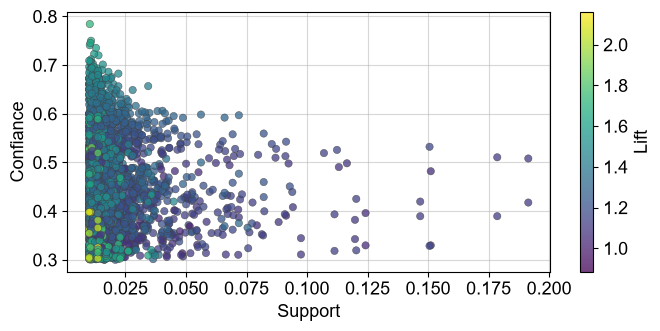

In [13]:
fig, ax = plt.subplots(figsize=(7, 3.5))

nuage = ax.scatter(rules.support, rules.confidence, c=rules.lift,
                   cmap='viridis', s=28, alpha=0.75,
                   edgecolors='0.25', linewidths=0.4, zorder=3)
ax.set_xlabel('Support')
ax.set_ylabel('Confiance')
ax.grid(alpha=0.5, zorder=0)
cbar = fig.colorbar(nuage, ax=ax)
cbar.set_label('Lift')
fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap13_ScatterLiftSupport')

plt.show()

<hr style='border-top:4px solid #1F77B4;'>